# Poprawiony notebook: przewidywanie sentymentu linków Reddit

Ten notebook jest uporządkowaną wersją pracy z `PBL_dataset_analysis.ipynb`. Zostawiamy główną ideę oryginału: analizę sentymentu postów Reddit oraz sprawdzenie, czy da się przewidzieć `LINK_SENTIMENT` różnymi metodami.

W notebooku porównujemy podejścia od najprostszych do bardziej złożonych:

- klasyczny baseline większościowy,
- prostą regułę na podstawie VADER,
- gotowy wynik modelu Hugging Face zapisany w kolumnie `Content_Sentiment`,
- modele uczenia maszynowego na cechach tekstowych/LIWC/Properties,
- modele TF-IDF uczone na tytule i treści,
- model łączący TF-IDF oraz cechy liczbowe.

Najważniejsza metryka to `negative_f1`, czyli F1 dla klasy negatywnej. Dane są mocno niezbalansowane, dlatego sama `accuracy` może być myląca.


## 1. Import bibliotek i ustawienia

Kod jest możliwie prosty i podobny do oryginału: używamy `pandas`, `scikit-learn`, `classification_report` i `confusion_matrix`. Modele z Hugging Face są pokazane jako opcjonalne komórki na końcu, ale domyślnie ich nie uruchamiamy, żeby notebook działał lokalnie bez pobierania dużych modeli.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)


## 2. Wczytanie danych

W oryginalnym notebooku pojawiało się kilka ścieżek z Google Colab i Dysku Google. Tutaj używamy lokalnej bazy z projektu: `database/NajnowszaWersjaBazy1205.csv`. Jeśli ktoś uruchamia notebook z innego katalogu, ścieżka jest sprawdzana w kilku prostych wariantach.


In [2]:
possible_paths = [
    Path("database/NajnowszaWersjaBazy1205.csv"),
    Path("../database/NajnowszaWersjaBazy1205.csv"),
    Path("NajnowszaWersjaBazy1205.csv"),
]

DATA_PATH = None
for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError("Nie znaleziono pliku NajnowszaWersjaBazy1205.csv")

print("Wczytuję dane z:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
print("Rozmiar danych:", df.shape)
df.head()


Wczytuję dane z: database\NajnowszaWersjaBazy1205.csv
Rozmiar danych: (49918, 95)


,POST_ID,Content_Sentiment,TIMESTAMP,Content_Score,Raw_Content,Raw_Title,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,LINK_SENTIMENT,Number of characters,Number of characters without counting white space,Fraction of alphabetical characters,Fraction of digits,Fraction of uppercase characters,Fraction of white spaces,"Fraction of special characters, such as comma, exclamation mark, etc.",Number of words,Number of unique works,Number of long words (at least 6 characters),Average word length,Number of unique stopwords,Fraction of stopwords,Number of sentences,Number of long sentences (at least 10 words),Average number of characters per sentence,Average number of words per sentence,Automated readability index,Positive sentiment calculated by VADER,Negative sentiment calculated by VADER,Compound sentiment calculated by VADER,LIWC_Funct,LIWC_Pronoun,LIWC_Ppron,LIWC_I,LIWC_We,LIWC_You,LIWC_SheHe,LIWC_They,LIWC_Ipron,LIWC_Article,...,LIWC_Humans,LIWC_Affect,LIWC_Posemo,LIWC_Negemo,LIWC_Anx,LIWC_Anger,LIWC_Sad,LIWC_CogMech,LIWC_Insight,LIWC_Cause,LIWC_Discrep,LIWC_Tentat,LIWC_Certain,LIWC_Inhib,LIWC_Incl,LIWC_Excl,LIWC_Percept,LIWC_See,LIWC_Hear,LIWC_Feel,LIWC_Bio,LIWC_Body,LIWC_Health,LIWC_Sexual,LIWC_Ingest,LIWC_Relativ,LIWC_Motion,LIWC_Space,LIWC_Time,LIWC_Work,LIWC_Achiev,LIWC_Leisure,LIWC_Home,LIWC_Money,LIWC_Relig,LIWC_Death,LIWC_Assent,LIWC_Dissent,LIWC_Nonflu,LIWC_Filler
0,1u4nrps,0,2013-12-31 16:39:58,0.884326,RANKED 5s Team looking for a GOLD v + CC JUNGL...,Ranked 5s Serious Team Looking For Gold v + CC...,leagueoflegends,teamredditteams,1,345.0,298.0,0.756522,0.017391,0.086957,0.150725,0.075362,57.0,53.0,10.0,4.789474,15.0,0.315789,1.0,1.0,345.000000,57.000000,35.577895,0.073,0.080,0.1748,0.344828,0.051724,0.034483,0.000000,0.034483,0.000000,0.000000,0.000000,0.017241,0.051724,...,0.000000,0.051724,0.017241,0.034483,0.000000,0.0,0.017241,0.189655,0.034483,0.000000,0.034483,0.034483,0.000000,0.000000,0.068966,0.051724,0.034483,0.034483,0.0,0.000000,0.017241,0.017241,0.0,0.0,0.000000,0.068966,0.017241,0.051724,0.000000,0.051724,0.068966,0.034483,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
1,1u4sjvs,0,2013-12-31 17:37:55,0.823999,It was suggested that I cross post [THIS](http...,XPOST from CFB - QUESTION: Can someone help me...,nfl,cfb,1,1124.0,949.0,0.772242,0.001779,0.057829,0.179715,0.046263,191.0,125.0,34.0,4.623037,36.0,0.366492,15.0,9.0,73.200000,12.733333,12.654154,0.153,0.026,0.9672,0.526042,0.109375,0.041667,0.031250,0.000000,0.005208,0.010417,0.000000,0.067708,0.057292,...,0.000000,0.052083,0.041667,0.010417,0.010417,0.0,0.000000,0.203125,0.046875,0.000000,0.036458,0.046875,0.015625,0.005208,0.036458,0.031250,0.015625,0.010417,0.0,0.000000,0.005208,0.005208,0.0,0.0,0.000000,0.104167,0.015625,0.052083,0.036458,0.026042,0.031250,0.020833,0.000000,0.000000,0.0,0.0,0.0,0.0,0.020833,0.005208
2,1u4qkd,1,2013-12-31 18:18:37,0.560457,I need your help!!!\n\nhttp://www.reddit.com/r...,Happy new years you cunts 1,theredlion,soccer,-1,101.0,98.0,0.742574,0.019802,0.049505,0.059406,0.178218,14.0,14.0,2.0,5.714286,1.0,0.071429,2.0,0.0,49.500000,7.000000,16.049286,0.472,0.000,0.5538,0.066667,0.066667,0.066667,0.066667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.066667,0.000000,0.000000,0.066667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.066667,0.066667,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.066667,0.000000,0.066667,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
3,1u4w7bs,0,2013-12-31 18:35:44,0.515756,I have worked as a commercial and residential ...,[SS] Starting a pool to buy the dogehouse. Lis...,dogemarket,dogecoin,1,1328.0,1110.0,0.768825,0.014307,0.075301,0.180723,0.036145,234.0,160.0,39.0,4.495726,34.0,0.354701,13.0,8.0,100.230769,18.000000,14.300256,0.100,0.008,0.9323,0.485106,0.110638,0.080851,0.046809,0.004255,0.029787,0.000000,0.000000,0.029787,0.055319,...,0.008511,0.042553,0.038298,0.000000,0.00

## 3. Przygotowanie celu predykcji

Oryginalna kolumna `LINK_SENTIMENT` ma wartości `-1` i `1`. Dla modeli tworzymy prostą etykietę binarną:

- `1` oznacza link negatywny (`LINK_SENTIMENT == -1`),
- `0` oznacza link nienegatywny (`LINK_SENTIMENT == 1`).

Takie kodowanie ułatwia liczenie metryk dla klasy negatywnej.


In [3]:
required_columns = ["LINK_SENTIMENT", "Raw_Title", "Raw_Content"]
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Brakuje wymaganych kolumn: {missing_columns}")

df = df.copy()
df["Raw_Title"] = df["Raw_Title"].fillna("").astype(str)
df["Raw_Content"] = df["Raw_Content"].fillna("").astype(str)
df["combined_text"] = df["Raw_Title"] + "\n" + df["Raw_Content"]
df["is_negative_link"] = (df["LINK_SENTIMENT"] == -1).astype(int)

sentiment_counts = pd.DataFrame({
    "LINK_SENTIMENT": df["LINK_SENTIMENT"].value_counts().sort_index(),
    "is_negative_link": df["is_negative_link"].value_counts().sort_index(),
})

display(sentiment_counts)
print("Udział klasy negatywnej:", round(df["is_negative_link"].mean(), 4))


,LINK_SENTIMENT,is_negative_link
-1,3854.0,NaN
0,NaN,46064.0
1,46064.0,3854.0


Udział klasy negatywnej: 0.0772


## 4. Podział na zbiór treningowy i testowy

Używamy `train_test_split` ze stratyfikacją, żeby w zbiorze treningowym i testowym zachować podobny udział klasy negatywnej. To ważne, bo negatywne linki są rzadsze.


In [4]:
X = df.copy()
y = df["is_negative_link"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Udział negatywnych w train:", round(y_train.mean(), 4))
print("Udział negatywnych w test:", round(y_test.mean(), 4))


Train: (39934, 97) Test: (9984, 97)
Udział negatywnych w train: 0.0772
Udział negatywnych w test: 0.0772


## 5. Funkcja do liczenia metryk

Porównujemy modele w jednej tabeli. Oprócz `accuracy` liczymy też `macro_f1`, `weighted_f1` oraz metryki tylko dla klasy negatywnej. W tym zadaniu `negative_f1` jest najważniejsze, bo zależy nam na rozpoznawaniu rzadkiej klasy negatywnej.


In [5]:
def evaluate_predictions(model_name, y_true, y_pred):
    y_pred = np.asarray(y_pred).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "negative_precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "negative_recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "negative_f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

results = []
predictions = pd.DataFrame({
    "POST_ID": X_test["POST_ID"] if "POST_ID" in X_test.columns else X_test.index,
    "Raw_Title": X_test["Raw_Title"],
    "LINK_SENTIMENT": X_test["LINK_SENTIMENT"],
    "true_is_negative": y_test,
})

model_predictions = {}


## 6. Baseline'y: najprostsze metody bez właściwego uczenia

Najpierw sprawdzamy metody referencyjne. One są potrzebne, żeby wiedzieć, czy modele ML faktycznie dają wartość.

- `Dummy most frequent` zawsze wybiera najczęstszą klasę.
- `VADER compound baseline` używa klasycznej analizy sentymentu zapisanej w kolumnie `Compound sentiment calculated by VADER`.
- `HF Content_Sentiment direct baseline` używa gotowego sentymentu treści, który w bazie został wcześniej policzony modelem transformerowym.


In [6]:
# Baseline 1: zawsze najczęstsza klasa
most_frequent = DummyClassifier(strategy="most_frequent")
most_frequent.fit(X_train, y_train)
pred_dummy = most_frequent.predict(X_test)
results.append(evaluate_predictions("Dummy most frequent", y_test, pred_dummy))
predictions["pred_dummy"] = pred_dummy
model_predictions["Dummy most frequent"] = pred_dummy

# Baseline 2: klasyczna analiza sentymentu VADER
vader_column = "Compound sentiment calculated by VADER"
if vader_column in X_test.columns:
    pred_vader = (pd.to_numeric(X_test[vader_column], errors="coerce").fillna(0) < -0.05).astype(int)
    results.append(evaluate_predictions("VADER compound direct baseline", y_test, pred_vader))
    predictions["pred_vader"] = pred_vader.to_numpy()
    model_predictions["VADER compound direct baseline"] = pred_vader.to_numpy()
else:
    print("Brak kolumny VADER, pomijam baseline VADER.")

# Baseline 3: gotowy sentyment treści z modelu Hugging Face zapisany w bazie
if "Content_Sentiment" in X_test.columns:
    pred_hf_direct = (pd.to_numeric(X_test["Content_Sentiment"], errors="coerce").fillna(0) == -1).astype(int)
    results.append(evaluate_predictions("HF Content_Sentiment direct baseline", y_test, pred_hf_direct))
    predictions["pred_hf_direct"] = pred_hf_direct.to_numpy()
    model_predictions["HF Content_Sentiment direct baseline"] = pred_hf_direct.to_numpy()
else:
    print("Brak kolumny Content_Sentiment, pomijam direct baseline HF.")

pd.DataFrame(results).sort_values(["negative_f1", "macro_f1"], ascending=False)


,model,accuracy,macro_f1,weighted_f1,negative_precision,negative_recall,negative_f1,tn,fp,fn,tp
2,HF Content_Sentiment direct baseline,0.823217,0.573906,0.849497,0.184645,0.377432,0.247976,7928,1285,480,291
1,VADER compound direct baseline,0.765124,0.547120,0.812804,0.155731,0.461738,0.232908,7283,1930,415,356
0,Dummy most frequent,0.922776,0.479919,0.885715,0.000000,0.000000,0.000000,9213,0,771,0


## 7. Wybór cech liczbowych

Do modeli typu `Properties + ...` używamy gotowych cech liczbowych z bazy: właściwości tekstu, VADER, LIWC i inne kolumny liczbowe. Nie dodajemy do nich `LINK_SENTIMENT`, bo to byłby przeciek celu. Osobno trzymamy `Content_Sentiment` i `Content_Score`, bo to wynik wcześniejszego modelu Hugging Face.


In [7]:
excluded_numeric_columns = {
    "LINK_SENTIMENT",
    "is_negative_link",
    "Content_Sentiment",
    "Content_Score",
}

numeric_features = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col not in excluded_numeric_columns
]

hf_features = [col for col in ["Content_Sentiment", "Content_Score"] if col in df.columns]

print("Liczba cech liczbowych Properties/LIWC/VADER:", len(numeric_features))
print("Cechy HF dostępne w bazie:", hf_features)
print(numeric_features[:20])


Liczba cech liczbowych Properties/LIWC/VADER: 86
Cechy HF dostępne w bazie: ['Content_Sentiment', 'Content_Score']
['Number of characters', 'Number of characters without counting white space', 'Fraction of alphabetical characters', 'Fraction of digits', 'Fraction of uppercase characters', 'Fraction of white spaces', 'Fraction of special characters, such as comma, exclamation mark, etc.', 'Number of words', 'Number of unique works', 'Number of long words (at least 6 characters)', 'Average word length', 'Number of unique stopwords', 'Fraction of stopwords', 'Number of sentences', 'Number of long sentences (at least 10 words)', 'Average number of characters per sentence', 'Average number of words per sentence', 'Automated readability index', 'Positive sentiment calculated by VADER', 'Negative sentiment calculated by VADER']


## 8. Modele uczenia maszynowego

Poniżej trenujemy kilka prostych modeli. Zostają one blisko oryginalnego notebooka: mamy Decision Tree, Random Forest, Logistic Regression, Linear SVC oraz TF-IDF na tekście.

W modelach ustawiamy `class_weight="balanced"`, bo klasa negatywna jest dużo rzadsza niż pozytywna.


In [8]:
numeric_pipeline_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_pipeline_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

models = {
    "Properties + Logistic Regression balanced": Pipeline([
        ("prep", ColumnTransformer([
            ("num", numeric_pipeline_scaled, numeric_features),
        ])),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Properties + Decision Tree balanced": Pipeline([
        ("prep", ColumnTransformer([
            ("num", numeric_pipeline_tree, numeric_features),
        ])),
        ("clf", DecisionTreeClassifier(max_depth=12, min_samples_leaf=10, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Properties + Random Forest balanced": Pipeline([
        ("prep", ColumnTransformer([
            ("num", numeric_pipeline_tree, numeric_features),
        ])),
        ("clf", RandomForestClassifier(
            n_estimators=150,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ]),
    "TF-IDF word 1-2 + Logistic Regression balanced": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, min_df=2, ngram_range=(1, 2), sublinear_tf=True)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "TF-IDF word 1-2 + Linear SVC balanced": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, min_df=2, ngram_range=(1, 2), sublinear_tf=True)),
        ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "TF-IDF + Properties + Logistic Regression balanced": Pipeline([
        ("prep", ColumnTransformer([
            ("text", TfidfVectorizer(max_features=30000, min_df=2, ngram_range=(1, 2), sublinear_tf=True), "combined_text"),
            ("num", numeric_pipeline_scaled, numeric_features),
        ])),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
}

if hf_features:
    models["HF Content sentiment + Logistic Regression balanced"] = Pipeline([
        ("prep", ColumnTransformer([
            ("hf", numeric_pipeline_scaled, hf_features),
        ])),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ])

    models["HF Content sentiment + Properties + Logistic Regression balanced"] = Pipeline([
        ("prep", ColumnTransformer([
            ("hf", numeric_pipeline_scaled, hf_features),
            ("num", numeric_pipeline_scaled, numeric_features),
        ])),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ])

print("Liczba trenowanych modeli:", len(models))


Liczba trenowanych modeli: 8


In [9]:
for name, model in models.items():
    print("Trenuję:", name)

    if name.startswith("TF-IDF word"):
        model.fit(X_train["combined_text"], y_train)
        pred = model.predict(X_test["combined_text"])
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    results.append(evaluate_predictions(name, y_test, pred))
    safe_name = (
        name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("-", "_")
        .replace("/", "_")
    )
    predictions[f"pred_{safe_name}"] = pred
    model_predictions[name] = pred

comparison = pd.DataFrame(results).sort_values(["negative_f1", "macro_f1"], ascending=False)
comparison.to_csv(OUTPUT_DIR / "model_comparison_poprawiony.csv", index=False)

display(comparison)
print("Zapisano:", OUTPUT_DIR / "model_comparison_poprawiony.csv")


Trenuję: Properties + Logistic Regression balanced
Trenuję: Properties + Decision Tree balanced
Trenuję: Properties + Random Forest balanced
Trenuję: TF-IDF word 1-2 + Logistic Regression balanced
Trenuję: TF-IDF word 1-2 + Linear SVC balanced
Trenuję: TF-IDF + Properties + Logistic Regression balanced
Trenuję: HF Content sentiment + Logistic Regression balanced
Trenuję: HF Content sentiment + Properties + Logistic Regression balanced


,model,accuracy,macro_f1,weighted_f1,negative_precision,negative_recall,negative_f1,tn,fp,fn,tp
6,TF-IDF word 1-2 + Logistic Regression balanced,0.848357,0.648301,0.872587,0.279263,0.609598,0.383048,8000,1213,301,470
8,TF-IDF + Properties + Logistic Regression bala...,0.837841,0.638850,0.865524,0.264706,0.618677,0.370773,7888,1325,294,477
7,TF-IDF word 1-2 + Linear SVC balanced,0.890725,0.647941,0.895147,0.326464,0.390402,0.355582,8592,621,470,301
10,HF Content sentiment + Properties + Logistic R...,0.738181,0.562937,0.796947,0.181252,0.679637,0.286182,6846,2367,247,524
3,Properties + Logistic Regression balanced,0.731671,0.556097,0.792153,0.174847,0.665370,0.276923,6792,2421,258,513
2,HF Content_Sentiment direct baseline,0.823217,0.573906,0.849497,0.184645,0.377432,0.247976,7928,1285,480,291
1,VADER compound direct baseline,0.765124,0.547120,0.812804,0.155731,0.461738,0.232908,7283,1930,415,356
9,HF Content sentiment + Logistic Regression bal...,0.699018,0.522069,0.767963,0.144041,0.586252,0.231261,6527,2686,319,452
4,Properties + Decision Tree balanced,0.688602,0.511362,0.760199,0.134687,0.559014,0.217074,6444,2769,340,431
5,Properties + Random Forest balanced,0.922977,0.530175,0.893417,0.511905,0.055772,0.100585,9172,41,728,43


Zapisano: outputs\model_comparison_poprawiony.csv


## 9. Wizualne porównanie modeli

Na wykresie pokazujemy `negative_f1`, czyli metrykę najbardziej związaną z wykrywaniem negatywnych linków. Przy danych niezbalansowanych model z najwyższą accuracy nie musi być najlepszy praktycznie.


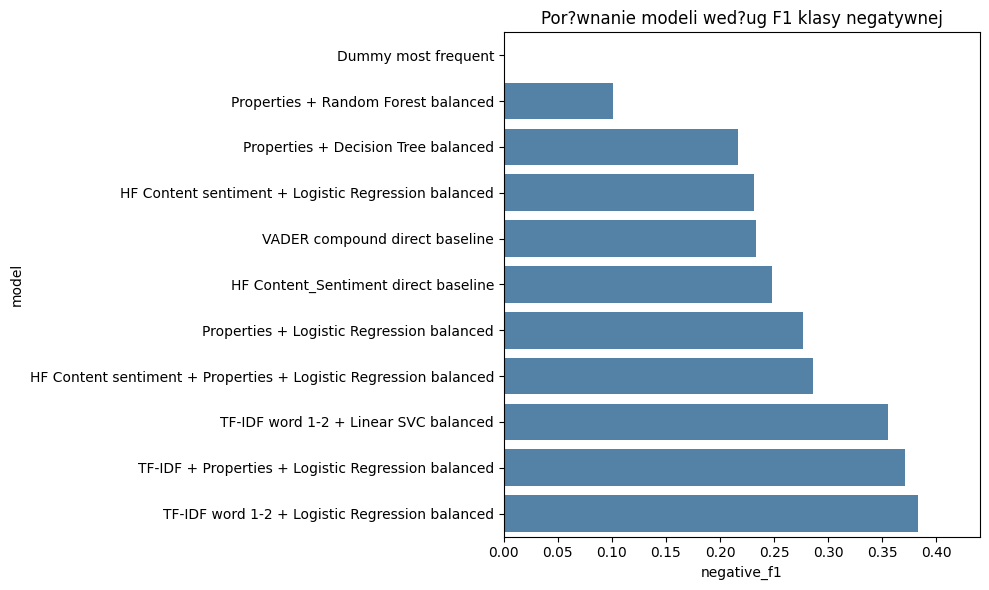

In [10]:
plt.figure(figsize=(10, 6))
plot_data = comparison.sort_values("negative_f1", ascending=True)
sns.barplot(data=plot_data, x="negative_f1", y="model", color="steelblue")
plt.title("Porównanie modeli według F1 klasy negatywnej")
plt.xlabel("negative_f1")
plt.ylabel("model")
plt.xlim(0, max(0.05, plot_data["negative_f1"].max() * 1.15))
plt.tight_layout()
plt.show()


## 10. Najlepszy model i raport klasyfikacji

Teraz wybieramy model z najwyższym `negative_f1`. Wypisujemy `classification_report` oraz macierz pomyłek, żeby sprawdzić, ile przypadków negatywnych model znajduje, a ile pomija.


In [11]:
best_row = comparison.iloc[0]
best_model_name = best_row["model"]
best_pred = model_predictions[best_model_name]

print("Najlepszy model według negative_f1:")
display(best_row.to_frame().T)

print("\nClassification report dla najlepszego modelu:")
print(classification_report(y_test, best_pred, target_names=["not_negative", "negative"], zero_division=0))

cm = confusion_matrix(y_test, best_pred, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["true_not_negative", "true_negative"], columns=["pred_not_negative", "pred_negative"])
display(cm_df)


Najlepszy model według negative_f1:


,model,accuracy,macro_f1,weighted_f1,negative_precision,negative_recall,negative_f1,tn,fp,fn,tp
6,TF-IDF word 1-2 + Logistic Regression balanced,0.848357,0.648301,0.872587,0.279263,0.609598,0.383048,8000,1213,301,470



Classification report dla najlepszego modelu:
              precision    recall  f1-score   support

not_negative       0.96      0.87      0.91      9213
    negative       0.28      0.61      0.38       771

    accuracy                           0.85      9984
   macro avg       0.62      0.74      0.65      9984
weighted avg       0.91      0.85      0.87      9984



,pred_not_negative,pred_negative
true_not_negative,8000,1213
true_negative,301,470


## 11. Przykładowe przewidywania

Poniżej zapisujemy predykcje wszystkich modeli dla zbioru testowego. Dzięki temu można ręcznie sprawdzić, gdzie modele się zgadzają, a gdzie dają różne decyzje.


In [12]:
predictions.to_csv(OUTPUT_DIR / "predykcje_sentymentu_poprawiony.csv", index=False)
print("Zapisano:", OUTPUT_DIR / "predykcje_sentymentu_poprawiony.csv")

prediction_columns = [col for col in predictions.columns if col.startswith("pred_")]
preview_columns = ["POST_ID", "Raw_Title", "LINK_SENTIMENT", "true_is_negative"] + prediction_columns[:6]
display(predictions[preview_columns].head(20))


Zapisano: outputs\predykcje_sentymentu_poprawiony.csv


,POST_ID,Raw_Title,LINK_SENTIMENT,true_is_negative,pred_dummy,pred_vader,pred_hf_direct,pred_properties_plus_logistic_regression_balanced,pred_properties_plus_decision_tree_balanced,pred_properties_plus_random_forest_balanced
38721,2fwmnms,"""I'm not some Joe Smo ""commie hater"" that does...",1,0,0,0,0,0,0,0
36948,2exjqus,Corporate ownership of /r/funny is pretty much...,1,0,0,0,0,1,0,0
13199,2265sh,It's in women's DNA to scream and get in the w...,-1,1,0,1,1,1,1,0
29944,2b7bdss,"July 20 19:00 UTC - Dec`s #01, FFA, Vanilla+ T...",1,0,0,0,0,0,0,0
46717,2kjfbps,Any Schick Adjustable fans out there? I have o...,1,0,0,0,0,0,0,0
43582,2iq400,[WP] A massive raid on ISIS camps led by Iraqi...,-1,1,0,0,0,0,0,0
44546,2jbi9hs,I cut off my healthy breasts at age 28 to redu...,1,0,0,1,0,0,0,0
11245,2128vxs,Send small letters!,1,0,0,0,0,0,0,0
7838,1z4srrs,Can and would the US government permanently ta...,1,0,0,0,0,0,0,0
5352,1xjiuts,Weekly build suggestion/practice/analysis [x/p...,1,0,0,0,0,0,0,0


## 12. Opcjonalnie: ponowne uruchomienie modelu Hugging Face

Oryginalny notebook używał modeli `siebert/sentiment-roberta-large-english` oraz `cardiffnlp/twitter-roberta-base-sentiment-latest`. Poniższa komórka pokazuje prostą wersję takiego podejścia, ale domyślnie jest wyłączona. Włączenie jej może pobierać model z internetu i długo działać bez GPU.


In [13]:
RUN_NEW_TRANSFORMER_ANALYSIS = False
HF_MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
HF_SAMPLE_SIZE = 20

if RUN_NEW_TRANSFORMER_ANALYSIS:
    from transformers import pipeline

    sentiment_pipeline = pipeline("sentiment-analysis", model=HF_MODEL_NAME, truncation=True)
    sample = df[["POST_ID", "combined_text"]].head(HF_SAMPLE_SIZE).copy()
    sample["hf_prediction"] = [sentiment_pipeline(text[:4000])[0] for text in sample["combined_text"]]
    display(sample)
else:
    print("Pominięto nowe uruchomienie Hugging Face. Ustaw RUN_NEW_TRANSFORMER_ANALYSIS = True, jeśli chcesz je włączyć.")


Pominięto nowe uruchomienie Hugging Face. Ustaw RUN_NEW_TRANSFORMER_ANALYSIS = True, jeśli chcesz je włączyć.


## 13. Opcjonalnie: embeddingi zdaniowe

W oryginalnym notebooku pojawiły się też embeddingi z Hugging Face. Poniższa komórka zostaje jako rozszerzenie. Domyślnie jest wyłączona, bo wymaga pakietu `sentence-transformers` i może długo liczyć embeddingi.


In [14]:
RUN_HF_EMBEDDINGS = False
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_SAMPLE_SIZE = 12000

if RUN_HF_EMBEDDINGS:
    from sentence_transformers import SentenceTransformer

    sample_df = df.sample(min(EMBEDDING_SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE).copy()
    sample_y = sample_df["is_negative_link"]

    X_train_text, X_test_text, y_train_emb, y_test_emb = train_test_split(
        sample_df["combined_text"],
        sample_y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=sample_y,
    )

    embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
    train_embeddings = embedding_model.encode(X_train_text.tolist(), batch_size=64, show_progress_bar=True, normalize_embeddings=True)
    test_embeddings = embedding_model.encode(X_test_text.tolist(), batch_size=64, show_progress_bar=True, normalize_embeddings=True)

    embedding_clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    embedding_clf.fit(train_embeddings, y_train_emb)
    embedding_pred = embedding_clf.predict(test_embeddings)

    embedding_result = evaluate_predictions(
        f"HF embeddings {EMBEDDING_MODEL_NAME} + Logistic Regression balanced",
        y_test_emb,
        embedding_pred,
    )
    display(pd.DataFrame([embedding_result]))
else:
    print("Pominięto benchmark embeddingów. Ustaw RUN_HF_EMBEDDINGS = True, jeśli chcesz go uruchomić.")


Pominięto benchmark embeddingów. Ustaw RUN_HF_EMBEDDINGS = True, jeśli chcesz go uruchomić.


## 14. Wnioski

W tym zadaniu trzeba uważać na niezbalansowanie klas. Model może mieć wysoką `accuracy`, ponieważ większość linków nie jest negatywna, ale jednocześnie może słabo wykrywać klasę negatywną. Dlatego do wyboru najlepszego modelu używamy przede wszystkim `negative_f1`, a pomocniczo `macro_f1`.

Najważniejsze porównanie znajduje się w pliku `outputs/model_comparison_poprawiony.csv`, a przykładowe przewidywania w `outputs/predykcje_sentymentu_poprawiony.csv`.


In [15]:
print("Ranking modeli według negative_f1:")
display(comparison[[
    "model",
    "accuracy",
    "macro_f1",
    "negative_precision",
    "negative_recall",
    "negative_f1",
]].sort_values(["negative_f1", "macro_f1"], ascending=False))

print("\nKrótki wniosek:")
print(f"Najlepszy wynik dla klasy negatywnej uzyskał model: {best_model_name}")
print(f"negative_f1 = {best_row['negative_f1']:.3f}, accuracy = {best_row['accuracy']:.3f}")
print("Jeśli model z najwyższą accuracy ma niskie negative_f1, nie powinien być wybierany jako najlepszy do wykrywania negatywnego sentymentu.")


Ranking modeli według negative_f1:


,model,accuracy,macro_f1,negative_precision,negative_recall,negative_f1
6,TF-IDF word 1-2 + Logistic Regression balanced,0.848357,0.648301,0.279263,0.609598,0.383048
8,TF-IDF + Properties + Logistic Regression bala...,0.837841,0.638850,0.264706,0.618677,0.370773
7,TF-IDF word 1-2 + Linear SVC balanced,0.890725,0.647941,0.326464,0.390402,0.355582
10,HF Content sentiment + Properties + Logistic R...,0.738181,0.562937,0.181252,0.679637,0.286182
3,Properties + Logistic Regression balanced,0.731671,0.556097,0.174847,0.665370,0.276923
2,HF Content_Sentiment direct baseline,0.823217,0.573906,0.184645,0.377432,0.247976
1,VADER compound direct baseline,0.765124,0.547120,0.155731,0.461738,0.232908
9,HF Content sentiment + Logistic Regression bal...,0.699018,0.522069,0.144041,0.586252,0.231261
4,Properties + Decision Tree balanced,0.688602,0.511362,0.134687,0.559014,0.217074
5,Properties + Random Forest balanced,0.922977,0.530175,0.511905,0.055772,0.100585



Krótki wniosek:
Najlepszy wynik dla klasy negatywnej uzyskał model: TF-IDF word 1-2 + Logistic Regression balanced
negative_f1 = 0.383, accuracy = 0.848
Jeśli model z najwyższą accuracy ma niskie negative_f1, nie powinien być wybierany jako najlepszy do wykrywania negatywnego sentymentu.
